In [1]:
import numpy as np
from dataclasses import dataclass
from typing import Optional
try:
    from scipy.integrate import quad
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False
from astropy import units as u
from astropy import constants as const

C_KMS = const.c.to(u.km/u.s).value

@dataclass
class CosmoParams:
    H0: float = 70.0            # [km/s/Mpc]
    Om0: float = 0.3            # Ω_m
    Ok0: float = 0.0            # Ω_k
    Or0: float = 0.0            # Ω_r (可忽略时设 0)
    # 暗能量状态方程：二选一
    w: Optional[float] = None      # 常数 w
    w0: float = -1.0            # CPL: w(a)=w0+wa(1-a)
    wa: float = 0.0

    def Ode0(self) -> float:
        return 1.0 - self.Om0 - self.Ok0 - self.Or0

def _rho_de_factor(z: float, cp: CosmoParams) -> float:
    """ρ_DE(z)/ρ_DE(0) 的无量纲演化因子。"""
    if cp.w is not None:  # 常数 w
        return (1.0 + z)**(3.0 * (1.0 + cp.w))
    # CPL: w(a)=w0+wa(1-a) => ρ_DE ∝ (1+z)^{3(1+w0+wa)} exp[-3 wa z/(1+z)]
    return (1.0 + z)**(3.0 * (1.0 + cp.w0 + cp.wa)) * np.exp(-3.0 * cp.wa * z / (1.0 + z))

def Ez(z: float, cp: CosmoParams) -> float:
    """E(z) = H(z)/H0."""
    de = cp.Ode0() * _rho_de_factor(z, cp)
    return np.sqrt(cp.Om0 * (1.0 + z)**3 + cp.Or0 * (1.0 + z)**4 + cp.Ok0 * (1.0 + z)**2 + de)

def _chi_quad(z: float, cp: CosmoParams) -> float:
    """无量纲共动径向距离 χ(z) = ∫_0^z dz'/E(z')."""
    if _HAS_SCIPY:
        val, _ = quad(lambda zp: 1.0 / Ez(zp, cp), 0.0, float(z), epsrel=1e-8, epsabs=0.0, limit=256)
        return val
    # 简单梯形积分后备方案
    zgrid = np.linspace(0.0, float(z), 4097)
    return np.trapz(1.0 / np.vectorize(Ez)(zgrid, cp), zgrid)

def _Sk(x: float, Ok0: float) -> float:
    """曲率函数 S_k(x)。注意这里的 x 是 √|Ω_k| χ。"""
    if abs(Ok0) < 1e-12:
        return x
    if Ok0 > 0.0:  # open, sinh
        return np.sinh(x)
    else:          # closed, sin
        return np.sin(x)

def D_M(z: float, cp: CosmoParams) -> float:
    """横向共动距离 D_M(z) [Mpc]."""
    chi = _chi_quad(z, cp)
    if abs(cp.Ok0) < 1e-12:
        return (C_KMS / cp.H0) * chi
    sqrtOk = np.sqrt(abs(cp.Ok0))
    return (C_KMS / cp.H0) * _Sk(sqrtOk * chi, cp.Ok0) / sqrtOk

def D_A(z: float, cp: CosmoParams) -> float:
    """角径距 D_A(0→z) [Mpc]."""
    return D_M(z, cp) / (1.0 + z)

def D_A12(z1: float, z2: float, cp: CosmoParams) -> float:
    """两红移间角径距 D_A(z1→z2) [Mpc], 需 z2>z1。"""
    if not (z2 > z1):
        raise ValueError("Require z2 > z1 for D_A12.")
    chi1 = _chi_quad(z1, cp)
    chi2 = _chi_quad(z2, cp)
    dchi = chi2 - chi1
    if abs(cp.Ok0) < 1e-12:
        DM12 = (C_KMS / cp.H0) * dchi
    else:
        sqrtOk = np.sqrt(abs(cp.Ok0))
        DM12 = (C_KMS / cp.H0) * _Sk(sqrtOk * dchi, cp.Ok0) / sqrtOk
    return DM12 / (1.0 + z2)

# ---- 封装常用距离 ----
def Dl(zl: float, cp: CosmoParams) -> float: return D_A(zl, cp)
def Ds(zs: float, cp: CosmoParams) -> float: return D_A(zs, cp)
def Dls(zl: float, zs: float, cp: CosmoParams) -> float: return D_A12(zl, zs, cp)

# =========================
# 1) 星系–星系透镜：R = Ds / Dls
# =========================
def galaxy_lens_distance_ratio(zl: float, zs: float, *,
                               H0: float, omega_m: float,
                               omega_k: float = 0.0, omega_r: float = 0.0,
                               w: Optional[float] = None, w0: float = -1.0, wa: float = 0.0) -> float:
    """
    返回 R = D_s / D_ls （无量纲），仅含宇宙学部分。
    注：真实建模还需乘以结构因子 F(γ, β_ani, θ_ap/θ_E) 才能与(θ_E, σ_ap)组合。
    """
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    return Ds(zs, cp) / Dls(zl, zs, cp)

# =========================
# 2) 时延 AGN：D_dt = (1+zl) Dl Ds / Dls
# =========================
def time_delay_distance(zl: float, zs: float, *,
                        H0: float, omega_m: float,
                        omega_k: float = 0.0, omega_r: float = 0.0,
                        w: Optional[float] = None, w0: float = -1.0, wa: float = 0.0) -> float:
    """
    返回时延距离 D_Δt [Mpc]： (1+zl) * Dl * Ds / Dls
    注意：观测上 D_Δt 还会被外会聚 κ_ext 等效缩放，建模需单独处理。
    """
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    return (1.0 + zl) * Dl(zl, cp) * Ds(zs, cp) / Dls(zl, zs, cp)

# =========================
# 3) 双源透镜：β_DSP = (D_ls2/D_s2) / (D_ls1/D_s1)
# =========================
def double_source_beta(zl: float, zs1: float, zs2: float, *,
                       H0: float, omega_m: float,
                       omega_k: float = 0.0, omega_r: float = 0.0,
                       w: Optional[float] = None, w0: float = -1.0, wa: float = 0.0) -> float:
    """
    返回双源透镜的宇宙学量 β_DSP （无量纲）。
    要求 zl < zs1 < zs2。
    """
    if not (zl < zs1 < zs2):
        raise ValueError("Require zl < zs1 < zs2 for double-source lensing.")
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    num = Dls(zl, zs2, cp) / Ds(zs2, cp)
    den = Dls(zl, zs1, cp) / Ds(zs1, cp)
    return num / den

import numpy as np

def _as_float(x):
    # 确保传给积分器的是标量 float
    return float(np.asarray(x))

def galaxy_lens_distance_ratio_vec(
    zl, zs, *, H0, omega_m, omega_k=0.0, omega_r=0.0,
    w=None, w0=-1.0, wa=0.0
):
    """
    向量化版本：返回 R = Ds/Dls（与 zl、zs 广播后的形状一致）。
    不满足 zs>zl 的元素返回 np.nan。
    """
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    zlA, zsA = np.broadcast_arrays(np.asarray(zl, float), np.asarray(zs, float))
    out = np.empty_like(zlA, dtype=float)
    it = np.nditer([zlA, zsA, out], flags=['multi_index'],
                   op_flags=[['readonly'], ['readonly'], ['writeonly']])
    for zl_i, zs_i, o in it:
        zl_f, zs_f = _as_float(zl_i), _as_float(zs_i)
        if zs_f <= zl_f:
            o[...] = np.nan
        else:
            # o[...] = Ds(zs_f, cp) / Dls(zl_f, zs_f, cp)
            o[...] = Dls(zl_f, zs_f, cp) / Ds(zs_f, cp)
    return out

def time_delay_distance_vec(
    zl, zs, *, H0, omega_m, omega_k=0.0, omega_r=0.0,
    w=None, w0=-1.0, wa=0.0
):
    """
    向量化版本：返回 D_dt [Mpc] = (1+zl) * Dl * Ds / Dls。
    不满足 zs>zl 的元素返回 np.nan。
    """
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    zlA, zsA = np.broadcast_arrays(np.asarray(zl, float), np.asarray(zs, float))
    out = np.empty_like(zlA, dtype=float)
    it = np.nditer([zlA, zsA, out], flags=['multi_index'],
                   op_flags=[['readonly'], ['readonly'], ['writeonly']])
    for zl_i, zs_i, o in it:
        zl_f, zs_f = _as_float(zl_i), _as_float(zs_i)
        if zs_f <= zl_f:
            o[...] = np.nan
        else:
            o[...] = (1.0 + zl_f) * Dl(zl_f, cp) * Ds(zs_f, cp) / Dls(zl_f, zs_f, cp)
    return out

def double_source_beta_vec(
    zl, zs1, zs2, *, H0, omega_m, omega_k=0.0, omega_r=0.0,
    w=None, w0=-1.0, wa=0.0
):
    """
    向量化版本：返回 β_DSP = (D_ls2/D_s2)/(D_ls1/D_s1)。
    仅当 zl < zs1 < zs2 时有效，否则该元素 np.nan。
    """
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    zlA, z1A, z2A = np.broadcast_arrays(np.asarray(zl, float),
                                        np.asarray(zs1, float),
                                        np.asarray(zs2, float))
    out = np.empty_like(zlA, dtype=float)
    it = np.nditer([zlA, z1A, z2A, out], flags=['multi_index'],
                   op_flags=[['readonly'], ['readonly'], ['readonly'], ['writeonly']])
    for zl_i, z1_i, z2_i, o in it:
        zl_f, z1_f, z2_f = _as_float(zl_i), _as_float(z1_i), _as_float(z2_i)
        if not (zl_f < z1_f < z2_f):
            o[...] = np.nan
        else:
            num = Dls(zl_f, z2_f, cp) / Ds(z2_f, cp)
            den = Dls(zl_f, z1_f, cp) / Ds(z1_f, cp)
            o[...] = num / den
    return out



In [2]:
import numpy as np
import math
from scipy.integrate import quad
from scipy.special import gamma as Gamma, exp1  # E1(x)
import astropy.units as u

# -------------------------
# constants
# -------------------------
c_kms = 299792.458  # km/s

# -------------------------
# Koopmans (2005) f^{-1} — vectorized
# -------------------------
def f_inv_vec(gamma3d, delta, beta):
    """
    Vectorized 1/f(gamma, delta, beta) of Koopmans (2005).
    Accepts scalars or arrays; returns array broadcast to common shape.
    """
    g  = np.asarray(gamma3d, dtype=float)
    d  = np.asarray(delta,    dtype=float)
    b  = np.asarray(beta,     dtype=float)
    # broadcast
    g, d, b = np.broadcast_arrays(g, d, b)

    xi   = g + d - 2.0
    pref = 1.0 / (2.0 * np.sqrt(np.pi))
    term1 = (xi - 3.0) * (xi - 2.0*b) / (d - 3.0)

    num = Gamma(xi/2.0) * Gamma((xi+2.0)/2.0)
    den = Gamma((xi+2.0)/2.0) * Gamma((xi-1.0)/2.0) - b * Gamma(xi/2.0) * Gamma((xi+1.0)/2.0)
    term2 = num / den

    term3 = Gamma((d-1.0)/2.0) * Gamma((g-1.0)/2.0) / (Gamma(d/2.0) * Gamma(g/2.0))

    out = pref * term1 * term2 * term3

    # domain masks: avoid singularities and non-finite results
    bad = (np.isclose(d, 3.0) |
           np.isclose(xi, 3.0) |
           np.isclose(xi, 2.0*b) |
           ~np.isfinite(out))
    return np.where(bad, np.nan, out)

# -------------------------
# w_phi distances
# w_phi(z) = -1 + (1+w0) exp(-alpha z)
# F(z) = exp{ 3 e^{alpha} (1+w0) [E1(alpha) - E1(alpha(1+z))] }
# H(z)^2/H0^2 = Om(1+z)^3 + Ok(1+z)^2 + (1-Om-Ok) F(z)
# -------------------------
def _da_wphi_scalar(z1, z2, w0, alpha, Ok, H0, Om, c=c_kms):
    """Scalar D_A(z1->z2) [Mpc] for the w_phi model (used internally)."""
    if np.isclose(z1, z2) or (z2 < z1):
        return 0.0

    Ode = 1.0 - Om - Ok
    A = 3.0 * np.exp(alpha) * (1.0 + w0)
    E1_alpha = exp1(alpha)

    def F_of_z(z):
        return np.exp(A * (E1_alpha - exp1(alpha * (1.0 + z))))

    def Ez_inv(z):
        Ez2 = Om*(1.0+z)**3 + Ok*(1.0+z)**2 + Ode*F_of_z(z)
        return 1.0/np.sqrt(Ez2)

    def sinn(ok, x):
        if ok < 0.0:
            k = np.sqrt(-ok);  return np.sin(k*x)/k
        if ok > 0.0:
            k = np.sqrt(ok);   return np.sinh(k*x)/k
        return x

    chi, _ = quad(Ez_inv, z1, z2, epsabs=0, epsrel=1e-8, limit=200)
    return (c / H0) * sinn(Ok, chi) / (1.0 + z2)

def da_wphi_vec(z1, z2, w0, alpha, Ok, H0, Om, c=c_kms):
    """
    Vectorized angular-diameter distance D_A(z1->z2) [Mpc] for w_phi cosmology.
    All inputs can be scalars or arrays; output broadcasts to common shape.
    """
    z1 = np.asarray(z1, dtype=float)
    z2 = np.asarray(z2, dtype=float)
    w0 = float(w0); alpha = float(alpha); Ok = float(Ok); H0 = float(H0); Om = float(Om); c = float(c)

    # broadcast z1 and z2 onto a common shape
    z1b, z2b = np.broadcast_arrays(z1, z2)
    out = np.empty_like(z1b, dtype=float)

    # flatten, compute per-pair, then reshape
    it = np.nditer([z1b, z2b, out], op_flags=[['readonly'], ['readonly'], ['writeonly']])
    for zi, zj, o in it:
        o[...] = _da_wphi_scalar(float(zi), float(zj), w0, alpha, Ok, H0, Om, c)
    return out

# -------------------------
# σ_los for spherical EPL (vectorized, w_phi cosmology)
# -------------------------
def sigma_EPL_wphi_vec(zl, zs, theta_E_arcsec, theta_ap_arcsec,
                       gamma3d, delta, beta,
                       w0, alpha, Ok, H0, Om, c=c_kms):
    """
    Luminosity-weighted LOS dispersion within circular aperture for spherical power-law mass,
    using w_phi cosmology distances. Accepts scalars or arrays; all inputs broadcast.
    """
    zl = np.asarray(zl, dtype=float)
    zs = np.asarray(zs, dtype=float)
    thE = np.asarray(theta_E_arcsec, dtype=float) * u.arcsec.to('rad')
    thA = np.asarray(theta_ap_arcsec, dtype=float) * u.arcsec.to('rad')

    # Broadcast all lens/source dependent arrays to a common shape
    zl, zs, thE, thA, gamma3d, delta, beta = np.broadcast_arrays(zl, zs, thE, thA, gamma3d, delta, beta)

    # Distances [Mpc]
    Ds  = da_wphi_vec(0.0, zs, w0, alpha, Ok, H0, Om, c)
    Dl  = da_wphi_vec(0.0, zl, w0, alpha, Ok, H0, Om, c)
    Dls = da_wphi_vec(zl,  zs, w0, alpha, Ok, H0, Om, c)

    # f^{-1}(γ,δ,β)
    fi = f_inv_vec(gamma3d, delta, beta)

    # Prefactor and final σ (km/s). All terms already broadcast.
    fac = (c**2) / (4.0 * np.pi) * (Ds / Dls) * thE**(gamma3d - 1.0) * thA**(2.0 - gamma3d)
    sigma = np.sqrt(fac / fi)

    # If zs <= zl, D_A(zl->zs)=0 → fac→∞；我们返回 NaN 以显式标记无效对
    bad_pair = (zs <= zl) | ~np.isfinite(Dls) | (Dls <= 0)
    return np.where(bad_pair, np.nan, sigma)


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- helpers: distances for w_phi ----------
def _da_wphi_01(z, cosmo):
    # 安全取值 + 类型
    w0    = float(cosmo.get('w0', -1.0))
    alpha = float(cosmo['alpha'])          # 若能进来，alpha 一定存在
    Ok    = float(cosmo.get('omega_k', 0.0))
    H0    = float(cosmo.get('H0', 70.0))
    Om    = float(cosmo.get('omega_m', cosmo.get('Om0', 0.3)))
    return da_wphi_vec(0.0, z, w0, alpha, Ok, H0, Om)

def _dls_wphi(zl, zs, cosmo):
    return da_wphi_vec(zl, zs,
                       float(cosmo.get('w0', -1.0)),
                       float(cosmo['alpha']),
                       float(cosmo.get('omega_k', 0.0)),
                       float(cosmo.get('H0', 70.0)),
                       float(cosmo.get('omega_m', cosmo.get('Om0', 0.3))))

# ---------- helpers: scalar observables (w_phi-aware) ----------
def R_scalar(zl, zs, cosmo):
    zl, zs = float(zl), float(zs)
    if 'alpha' in cosmo:  # w_phi
        Ds  = _da_wphi_01(zs, cosmo)
        Dls = _dls_wphi(zl, zs, cosmo)
        return float(Ds / Dls)
    else:                 # CPL / const-w
        # 只传 CPL 识别的键，避免 TypeError
        c = dict(H0=cosmo.get('H0', 70.0),
                 omega_m=cosmo.get('omega_m', cosmo.get('Om0', 0.3)),
                 omega_k=cosmo.get('omega_k', cosmo.get('Ok0', 0.0)),
                 omega_r=cosmo.get('omega_r', cosmo.get('Or0', 0.0)),
                 w=cosmo.get('w', None),
                 w0=cosmo.get('w0', -1.0),
                 wa=cosmo.get('wa', 0.0))
        return galaxy_lens_distance_ratio(zl, zs, **c)

def Ddt_scalar(zl, zs, cosmo):
    zl, zs = float(zl), float(zs)
    if 'alpha' in cosmo:  # w_phi
        Dl  = _da_wphi_01(zl, cosmo)
        Ds  = _da_wphi_01(zs, cosmo)
        Dls = _dls_wphi(zl, zs, cosmo)
        return float((1.0 + zl) * Dl * Ds / Dls)
    else:                 # CPL / const-w
        c = dict(H0=cosmo.get('H0', 70.0),
                 omega_m=cosmo.get('omega_m', cosmo.get('Om0', 0.3)),
                 omega_k=cosmo.get('omega_k', cosmo.get('Ok0', 0.0)),
                 omega_r=cosmo.get('omega_r', cosmo.get('Or0', 0.0)),
                 w=cosmo.get('w', None),
                 w0=cosmo.get('w0', -1.0),
                 wa=cosmo.get('wa', 0.0))
        return time_delay_distance(zl, zs, **c)

def beta_scalar(zl, zs1, zs2, cosmo):
    zl, zs1, zs2 = float(zl), float(zs1), float(zs2)
    if 'alpha' in cosmo:  # w_phi
        Dls1 = _dls_wphi(zl, zs1, cosmo); Ds1 = _da_wphi_01(zs1, cosmo)
        Dls2 = _dls_wphi(zl, zs2, cosmo); Ds2 = _da_wphi_01(zs2, cosmo)
        return float((Dls2/Ds2) / (Dls1/Ds1))
    else:                 # CPL / const-w
        c = dict(H0=cosmo.get('H0', 70.0),
                 omega_m=cosmo.get('omega_m', cosmo.get('Om0', 0.3)),
                 omega_k=cosmo.get('omega_k', cosmo.get('Ok0', 0.0)),
                 omega_r=cosmo.get('omega_r', cosmo.get('Or0', 0.0)),
                 w=cosmo.get('w', None),
                 w0=cosmo.get('w0', -1.0),
                 wa=cosmo.get('wa', 0.0))
        return double_source_beta(zl, zs1, zs2, **c)


# ===== NEW: dict -> CosmoParams, and Dl_scalar (w_phi aware) =====
def _dict_to_cp(c: dict) -> CosmoParams:
    return CosmoParams(
        H0  = float(c.get("H0", 70.0)),
        Om0 = float(c.get("omega_m", c.get("Om0", 0.3))),
        Ok0 = float(c.get("omega_k", c.get("Ok0", 0.0))),
        Or0 = float(c.get("omega_r", c.get("Or0", 0.0))),
        w   = c.get("w", None),
        w0  = float(c.get("w0", -1.0)),
        wa  = float(c.get("wa", 0.0)),
    )

def _use_wphi(cosmo: dict) -> bool:
    """Return True if we should use w_phi distances."""
    # 约定：只要存在 alpha，就按 w_phi 处理
    return ('alpha' in cosmo)

def Dl_scalar(zl, cosmo):
    """
    Angular-diameter distance to lens: D_l = D_A(0->z_l) [Mpc]
    - 若 cosmo 含 alpha → 使用 w_phi 的 da_wphi_vec 计算
    - 否则 → 使用标准 Dl(z, CosmoParams)
    """
    zl = float(zl)
    if zl <= 0:
        return np.nan

    if _use_wphi(cosmo):
        # 需要 da_wphi_vec 可用
        try:
            return float(da_wphi_vec(0.0, zl,
                                     float(cosmo.get('w0', -1.0)),
                                     float(cosmo['alpha']),
                                     float(cosmo.get('omega_k', 0.0)),
                                     float(cosmo.get('H0', 70.0)),
                                     float(cosmo.get('omega_m', cosmo.get('Om0', 0.3)))) )
        except NameError:
            # 没有导入 w_phi 的实现则回退（将不会依赖 alpha）
            pass

    cp = _dict_to_cp(dict(cosmo))  # fallback: CPL/const-w
    return Dl(zl, cp)

def _prep_xy(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    i = np.argsort(x)
    return x[i], y[i]

def _cosmo_with(cosmo_fid: dict, param: str, value: float) -> dict:
    """
    Return a new cosmology dict with `param` set to `value`.
    - 变 w0/wa 时删除 'w' 强制 CPL 分支
    - 变 alpha 时强制走 w_phi 分支，并保留 w0（若 fid 有）
    """
    c = dict(cosmo_fid)  # shallow copy
    c[param] = float(value)
    if param in ("w0", "wa"):
        c.pop("w", None)
        # 如果 fid 里有 alpha，保留它（支持“CPL+alpha”的边界情况也走 CPL）
        # 真正的 w_phi 由 alpha 的存在决定
    if param == "alpha":
        # 显式提示底层（如果你的实现需要）
        c["model"] = "wphi"
        # 确保有 w0（w_phi 里 F(z) 依赖 1+w0）
        c.setdefault("w0", cosmo_fid.get("w0", -1.0))
    return c

def _project_cosmo_for_param(param: str, cosmo_in: dict) -> dict:
    """
    根据要画的参数决定使用的宇宙学模型：
      - param == 'alpha'  -> 强制 w_phi：保留 alpha，删除 'wa' 和 'w'（避免混淆），加 model='wphi'
      - 其他参数          -> 强制 CPL/const-w：去掉 alpha & model（回到你的 CPL/const-w 路径）
    """
    c = dict(cosmo_in)
    if param == 'alpha':
        if 'alpha' not in c:
            raise ValueError("To sweep alpha you must provide a fiducial 'alpha' in cosmo_fid.")
        c['model'] = 'wphi'
        c.pop('wa', None)
        c.pop('w',  None)
    else:
        c.pop('alpha', None)
        c.pop('model', None)
    return c

def _compute_ratios_vs_param(param, grid, zl, zs, zs2, cosmo_fid):
    """
    For one parameter, return x=grid and FOUR ratio curves relative to the *projected* fiducial.
    """
    # 先把 fid 映射到该 panel 指定的模型
    cosmo_base = _project_cosmo_for_param(param, cosmo_fid)

    # build fiducial values once（在该模型下）
    R_fid    = R_scalar(zl, zs, cosmo_base)
    Ddt_fid  = Ddt_scalar(zl, zs, cosmo_base)
    beta_fid = beta_scalar(zl, zs, zs2, cosmo_base)
    Dl_fid   = Dl_scalar(zl, cosmo_base)

    R_ratio, Ddt_ratio, beta_ratio, Dl_ratio = [], [], [], []
    for val in grid:
        # 从“已投影到指定模型”的 fid 出发修改目标参数
        cvar = _cosmo_with(cosmo_base, param, val)

        try:
            R_var    = R_scalar(zl, zs, cvar)
            Ddt_var  = Ddt_scalar(zl, zs, cvar)
            beta_var = beta_scalar(zl, zs, zs2, cvar)
            Dl_var   = Dl_scalar(zl, cvar)
        except Exception:
            R_var = Ddt_var = beta_var = Dl_var = np.nan

        R_ratio.append(R_var / R_fid           if (np.isfinite(R_var)    and R_fid    != 0) else np.nan)
        Ddt_ratio.append(Ddt_var / Ddt_fid     if (np.isfinite(Ddt_var)  and Ddt_fid  != 0) else np.nan)
        beta_ratio.append(beta_var / beta_fid  if (np.isfinite(beta_var) and beta_fid != 0) else np.nan)
        Dl_ratio.append(Dl_var / Dl_fid        if (np.isfinite(Dl_var)   and Dl_fid   > 0) else np.nan)

    return (np.asarray(grid, float),
            np.asarray(R_ratio, float),
            np.asarray(Ddt_ratio, float),
            np.asarray(beta_ratio, float),
            np.asarray(Dl_ratio, float))


def plot_param_sweeps_2x2(zl, zs, zs2, cosmo_fid,
                          grids=None, sharey=False, figsize=(14,7)):
    """
    Make a 2x2 panel plot for parameters ['omega_m','w0','wa'].
    x-axis = parameter value; y-axis = ratio (var/fid).
    Each data subplot overlays FOUR curves: R, D_dt, beta_DSP, D_l.
    """
    params = ["omega_m", "w0", "wa"]
    titles = [r"$\Omega_m$", r"$w_0$", r"$w_a$"]

    # default grids (Ωk 移除，新增 alpha)
    default_grids = {
        "omega_m": np.linspace(0.1, 0.5, 161),
        "w0":      np.linspace(-2.0, 0.0, 161),
        "wa":      np.linspace(-1.0,  1.0, 161),
        "alpha":   np.linspace(1.0,   2.0, 161),
    }
    if grids is None:
        grids = default_grids
    else:
        for k, v in default_grids.items():
            grids.setdefault(k, v)

    # 若 fid 包含 alpha，则确保底层能识别 w_phi
    if 'alpha' in cosmo_fid:
        cosmo_fid = dict(cosmo_fid)
        cosmo_fid.setdefault('model', 'wphi')
        cosmo_fid.setdefault('w0', -0.95)  # 防 w0=-1 让 α 系数为 0 的退化

    fig, axes = plt.subplots(2, 2, figsize=figsize, sharey=sharey)
    axes = axes.ravel()

    for ax, p, ttl in zip(axes[:3], params, titles):
        xgrid = grids[p]
        x, yR, yD, yB, yL = _compute_ratios_vs_param(p, xgrid, zl, zs, zs2, cosmo_fid)

        # sort & clean
        xR, yR = _prep_xy(x, yR)
        xD, yD = _prep_xy(x, yD)
        xB, yB = _prep_xy(x, yB)
        xL, yL = _prep_xy(x, yL)

        ax.plot(xR, yR, lw=1.8, label=r"$\mathcal{D}$")
        ax.plot(xD, yD, lw=1.8, ls='--', label=r"$\mathcal{D}_{\Delta t}$")
        ax.plot(xB, yB, lw=1.8, ls=':',  label=r"$\mathcal{D}_{DSP}$")
        # ax.plot(xL, yL, lw=1.8, ls='-.', label=r"$D_l$")

        ax.axhline(1.0, color='k', lw=0.8, ls=':')
        ax.set_xlabel(ttl, fontsize=15)
        ax.set_ylabel(r"$\mathcal{R}/\mathcal{R}_{fid}$", fontsize=15)
        ax.tick_params(axis="both", labelsize=14)
        # ax.grid(alpha=0.3)

    # bottom-right panel: show legend instead of alpha subplot
    handles, labels = axes[0].get_legend_handles_labels()
    legend_ax = axes[3]
    legend_ax.axis('off')
    legend_ax.legend(handles, labels, loc='center', frameon=False, fontsize=15)

    plt.tight_layout(rect=[0.04, 0.04, 0.98, 0.94])
    plt.savefig("deviation.png", dpi=300, bbox_inches="tight")
    plt.show()


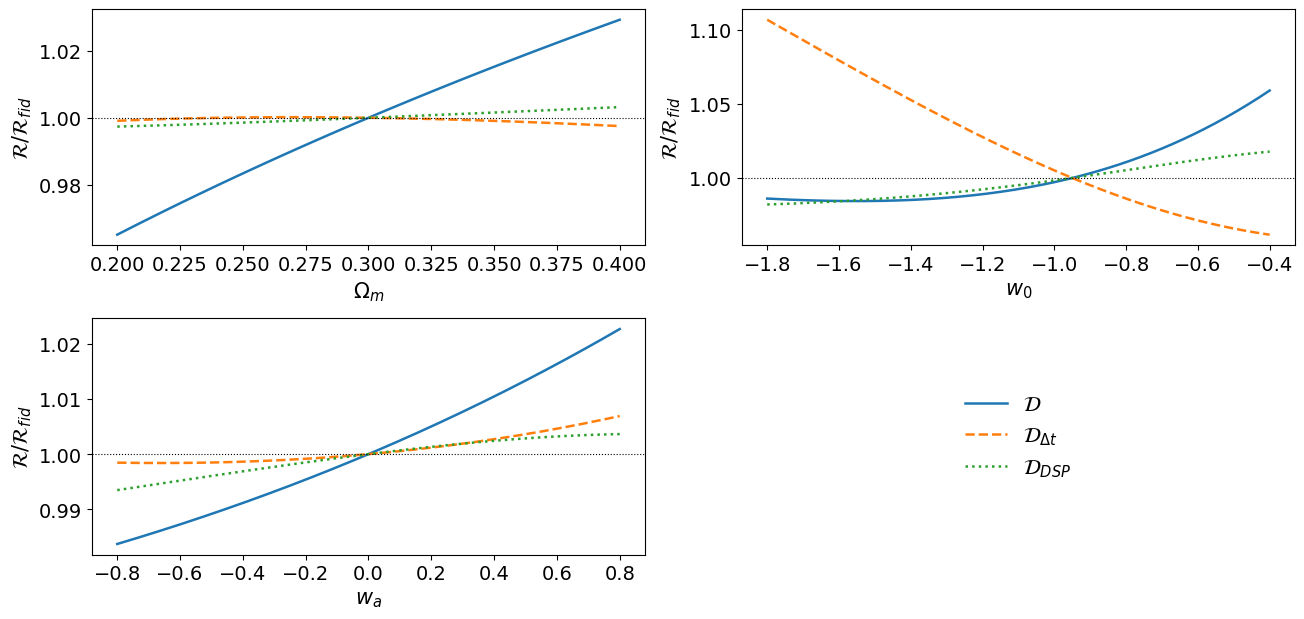

In [6]:
# Fiducial: use CPL so w0/wa sweeps are meaningful (remove 'w' if present)
cosmo_fid = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w0=-0.95, wa=0.0, alpha=1.45)

zl, zs, zs2 = 0.5, 1.0, 2.0

# (Optional) customize parameter grids
grids = {
    "omega_m": np.linspace(0.2, 0.4, 121),
    "omega_k": np.linspace(-0.05, 0.05, 121),
    "w0":      np.linspace(-1.8, -0.4, 141),
    "wa":      np.linspace(-0.8,  0.8, 141),
    "alpha":   np.linspace(1.35,  1.55, 101),
}

plot_param_sweeps_2x2(zl, zs, zs2, cosmo_fid, grids=grids, sharey=False)
